# Interconnection of port-Hamiltonian systems

This notebook will cover the implementation of interconnection schemes in this library.

In [1]:
include(joinpath(@__DIR__, "..", "src", "SystemModelling.jl"))

using .SystemModellingModule
using .SystemModellingModule.pHModule

In [4]:
a = [1.0 2.0; 3.0 4.0]
b = reshape([5.0; 6.0], :, 1)
c = reshape([7.0 8.0], 1, :)
d = reshape([9.0], 1, 1)

blockmatrix(a,b,c,d)

3×3 Matrix{Float64}:
 1.0  2.0  5.0
 3.0  4.0  6.0
 7.0  8.0  9.0

In [5]:
L = 1.0
C = 0.02533

R = 1.26 # underdamped
#R = 12.57 # critically damped
#R = 25.13 # overdamped
# Connecting an inductor into an capacitor

zeta = R/2 * sqrt(C/L)

display(zeta)

phs1 = inductor(L, s=1) 
phs2 = capacitor(C, s=-1);

0.10026702847895712

In [6]:
ports = [PortPair(1, 1)];

In [13]:
ph_connect = connect(phs1, phs2, pairs=ports)

J = ph_connect.J
G = ph_connect.G

display(G)

blockmatrix(-J, -G, G', zeros(2, 2))

2×2 Matrix{Float64}:
 1.0   0.0
 0.0  -1.0

4×4 Matrix{Float64}:
 -0.0   1.0  -1.0  -0.0
 -1.0  -0.0  -0.0   1.0
  1.0   0.0   0.0   0.0
  0.0  -1.0   0.0   0.0

In [5]:
ph_total = connect_resistor(ph_connect, 1, R)

pHDescriptorSystem{Float64, Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Matrix{Float64}}([1.0 0.0; 0.0 1.0], [0.0 -1.0; 1.0 0.0], [0.7936507936507936 0.0; 0.0 0.0], [1.0 0.0; 0.0 39.478878799842086], [1.0 0.0; 0.0 -1.0], [1.0 0.0; 0.0 39.478878799842086], 2, 2, :x_state)

In [6]:
ph_total.R

2×2 Matrix{Float64}:
 0.793651  0.0
 0.0       0.0

In [7]:
dt = 0.01

sim_total = DescriptorSimulator(ph_total, dt, :Gauss1);

In [8]:
x0 = [0.0, 1.0];
u = [0.0, 0.0]
tspan = 0.0:dt:10.0

t, states, output = simulate(sim_total, x0, u, tspan)



(0.0:0.01:10.0, [0.0 -0.39284216630630153 … 0.02477932066068193 0.01730840389434482; 1.0 0.9980357891684685 … 0.018395564420054314 0.018606003042829448], [0.0 -0.39284216630630153 … 0.02477932066068193 0.01730840389434482; -39.478878799842086 -39.40133395848672 … -0.7262362581940116 -0.7345441390773568])

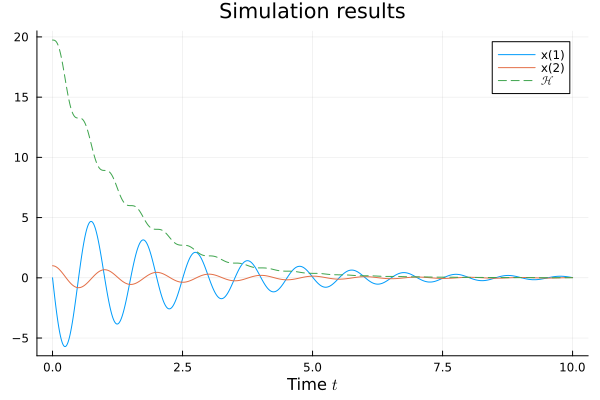

In [9]:
plot_results(t, states; sys=ph_total)

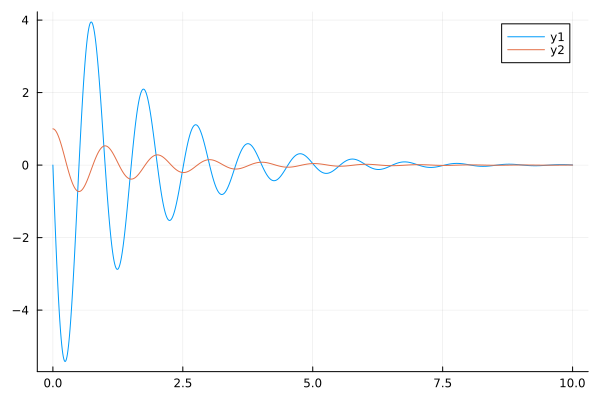

In [12]:
omega0 = 1/sqrt(L*C)
omegad = omega0*sqrt(1-zeta^2)
q(t) = exp.(-zeta*omega0*t).*(x0[2]*cos.(omegad*t) + x0[2]*(zeta*omega0/omegad)*sin.(omegad*t))
phi(t) = -L*x0[2]*(omega0^2/omegad)*exp.(-zeta*omega0.*t).*sin.(omegad.*t)


using Plots
plot(tspan, phi(tspan))
plot!(tspan, q(tspan))

In [11]:
# rethink the connection, we have artificial ports u1 u2 in the new system but it should be a closed one wihtout any ports, check reference and literature for theory!